In [88]:
install.packages(c("tidyverse", "caret", "randomForest", "e1071", "ggplot2", "lubridate"))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [89]:
 # Replace with actual file name
library(readr)

df <- read.csv("/content/period - Copy.csv")

In [90]:
df$Unusual_Bleeding <- ifelse(df$Unusual_Bleeding == "yes", 1, 0)
colSums(is.na(df))

number_of_peak                        Age 
                         0                          0 
           Length_of_cycle Estimated_day_of_ovulution 
                         0                          0 
    Length_of_Leutal_Phase           Length_of_menses 
                         0                          0 
          Unusual_Bleeding                     Height 
                         0                          0 
                    Weight                     Income 
                         0                          0 
                       BMI    Mean_of_length_of_cycle 
                         0                          0 
              Menses_score 
                         0

In [91]:
df$Last_Cycle_Start <- as.Date("2025-02-01") - df$Length_of_cycle  # assume the last cycle ended before today

In [92]:
df$Next_Cycle_Start <- df$Last_Cycle_Start + df$Length_of_cycle


In [93]:
head(df)

,number_of_peak,Age,Length_of_cycle,Estimated_day_of_ovulution,Length_of_Leutal_Phase,Length_of_menses,Unusual_Bleeding,Height,Weight,Income,BMI,Mean_of_length_of_cycle,Menses_score,Last_Cycle_Start,Next_Cycle_Start
,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<chr>,<dbl>,<int>,<dbl>,<int>,<dbl>,<date>,<date>
1,3,18,27,14,9,5,0,5 6,76,0,26.3,30,4,2025-01-05,2025-02-01
2,4,18,25,17,10,6,1,5 6,76,0,26.3,30,5,2025-01-07,2025-02-01
3,2,19,30,17,13,4,0,5 3,56,0,21.9,30,2,2025-01-02,2025-02-01
4,3,19,28,16,14,6,0,5 1,61,0,25.4,30,3,2025-01-04,2025-02-01
5,2,19,35,18,15,5,0,5'3,55,0,21.5,35,5,2024-12-28,2025-02-01
6,5,19,30,15,10,6,1,5'3,50,0,19.0,30,2,2025-01-02,2025-02-01


In [94]:
library(caret)
library(lubridate)
set.seed(123)

In [95]:
df$Cycle_Length <- as.numeric(df$Next_Cycle_Start - df$Last_Cycle_Start)  # Convert to numeric

trainIndex <- createDataPartition(df$Cycle_Length, p = 0.8, list = FALSE)
train <- df[trainIndex, ]
test <- df[-trainIndex, ]

# Train model
model <- train(Cycle_Length ~ Length_of_cycle + Estimated_day_of_ovulution + Length_of_Leutal_Phase,
               data = train, method = "lm")


In [96]:
# Function to predict next cycle
predict_next_cycle <- function(last_period_date) {
  predicted_cycle_length <- predict(model, newdata = test[1, ])  # Using test data as a sample
  next_period_date <- as.Date(last_period_date) + round(predicted_cycle_length)
  return(next_period_date)
}

# Get user input
user_last_period <- as.Date(readline(prompt = "Enter the start date of your last period (YYYY-MM-DD): "))

# Predict next period
next_period <- predict_next_cycle(user_last_period)
print(paste("Your next estimated period start date is:", next_period))


Enter the start date of your last period (YYYY-MM-DD): 2025-1-10
[1] "Your next estimated period start date is: 2025-02-06"


In [97]:
install.packages("plumber")
library(plumber)


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [98]:


# Convert categorical columns to factors
df$Unusual_Bleeding <- as.factor(df$Unusual_Bleeding)

# Check for missing values
df <- na.omit(df)

# Display summary
summary(df)


 number_of_peak       Age        Length_of_cycle Estimated_day_of_ovulution
 Min.   :1.000   Min.   :14.00   Min.   :22.00   Min.   : 7.00             
 1st Qu.:2.000   1st Qu.:19.00   1st Qu.:27.00   1st Qu.:14.00             
 Median :2.000   Median :19.00   Median :28.00   Median :15.00             
 Mean   :2.519   Mean   :19.33   Mean   :29.28   Mean   :15.14             
 3rd Qu.:3.000   3rd Qu.:20.00   3rd Qu.:30.00   3rd Qu.:16.00             
 Max.   :5.000   Max.   :25.00   Max.   :40.00   Max.   :22.00             
 Length_of_Leutal_Phase Length_of_menses Unusual_Bleeding    Height         
 Min.   : 7.00          Min.   :1.000    0:140            Length:162        
 1st Qu.:10.00          1st Qu.:5.000    1: 22            Class :character  
 Median :13.00          Median :5.000                     Mode  :character  
 Mean   :12.75          Mean   :5.062                                       
 3rd Qu.:14.00          3rd Qu.:6.000                                       
 Max. 

In [99]:
# Create PCOD risk score (1-100%)
df$PCOD_Risk <- ifelse(df$BMI > 25 & df$Length_of_cycle > 35, 1, 0)

# Define Cycle Irregularity (Yes/No)
df$Irregular_Cycle <- ifelse(df$Length_of_cycle > 32 | df$Length_of_cycle < 25, "Yes", "No")

# Define Overall Health Score (1-10)
df$Health_Score <- 10 - (df$Menses_score + df$PCOD_Risk * 3)
df$Health_Score <- ifelse(df$Health_Score < 1, 1, df$Health_Score)


In [100]:
# Safe numeric input function with validation
safe_numeric_input <- function(prompt, min_val, max_val) {
  while(TRUE) {
    val <- suppressWarnings(as.numeric(readline(prompt)))
    if(!is.na(val) && val >= min_val && val <= max_val) {
      return(val)
    }
    cat("Please enter a number between", min_val, "and", max_val, "\n")
  }
}

# Prediction function
predict_menstrual_health <- function(
  length_of_cycle,
  estimated_day_of_ovulation,
  length_of_luteal_phase,
  length_of_menses,
  unusual_bleeding,
  bmi,
  menses_score
) {
  # Calculate PCOD risk (simplified example)
  pcod_risk <- ifelse(bmi > 25 & length_of_cycle > 35, 75,
                     ifelse(bmi > 25 | length_of_cycle > 35, 50,
                            ifelse(unusual_bleeding == 1, 30, 10)))

  # Determine cycle irregularity
  irregular <- ifelse(length_of_cycle < 25 | length_of_cycle > 35 |
                      length_of_luteal_phase < 10 | length_of_luteal_phase > 16,
                     "Yes", "No")

  # Calculate health score (1-10)
  health_score <- 10 - (menses_score/2 +
                        ifelse(unusual_bleeding == 1, 2, 0) +
                        ifelse(irregular == "Yes", 1.5, 0))
  health_score <- max(1, min(10, round(health_score, 1)))

  return(list(
    PCOD_Risk_Score = paste0(pcod_risk, "%"),
    Cycle_Irregularity = irregular,
    Overall_Health_Score = paste0(health_score, "/10")
  ))
}

# Main function
menstrual_health_input <- function() {
  # Clear console
  cat("\014")

  # Display welcome message
  cat("🩺 Menstrual Health Prediction Tool 🩺\n")
  cat("-----------------------------------\n\n")
  cat("This tool helps you assess your menstrual health by analyzing\n")
  cat("key parameters of your menstrual cycle. It provides insights into:\n\n")
  cat("1. PCOD Risk Score: Likelihood of Polycystic Ovary Syndrome (0-100%)\n")
  cat("2. Cycle Irregularity: Potential cycle abnormalities (Yes/No)\n")
  cat("3. Overall Menstrual Health Score: General health assessment (1-10)\n\n")
  cat("Please provide the following detailed information:\n")
  cat("(Ensure values are within the specified ranges)\n\n")

  flush.console()
  readline("Press [Enter] to continue...\n")

  tryCatch({
    # Get user input with validation
    length_of_cycle <- safe_numeric_input("Length of Cycle (days, 21-35): ", 21, 35)
    estimated_day_of_ovulation <- safe_numeric_input("Estimated Day of Ovulation (days, 12-16): ", 12, 16)
    length_of_luteal_phase <- safe_numeric_input("Length of Luteal Phase (days, 12-16): ", 12, 16)
    length_of_menses <- safe_numeric_input("Length of Menses (days, 3-7): ", 3, 7)
    unusual_bleeding <- safe_numeric_input("Unusual Bleeding (0=No, 1=Yes): ", 0, 1)
    bmi <- safe_numeric_input("BMI (18.5-30): ", 18.5, 30)
    menses_score <- safe_numeric_input("Menses Score (1-10): ", 1, 10)

    # Get predictions
    results <- predict_menstrual_health(
      length_of_cycle,
      estimated_day_of_ovulation,
      length_of_luteal_phase,
      length_of_menses,
      unusual_bleeding,
      bmi,
      menses_score
    )

    # Display results
    cat("\n--- 📊 Prediction Results 📊 ---\n")
    cat("PCOD Risk Score:        ", results$PCOD_Risk_Score, "\n")
    cat("Cycle Irregularity:     ", results$Cycle_Irregularity, "\n")
    cat("Overall Health Score:   ", results$Overall_Health_Score, "\n\n")
    cat("🩺 Note: These results are for informational purposes only.\n")
    cat("  Always consult with a healthcare professional for medical advice.\n")

    return(results)

  }, error = function(e) {
    cat("\nError: ", conditionMessage(e), "\n")
    cat("Please restart the tool and enter valid values.\n")
    return(NULL)
  })
}

# Run the tool
menstrual_health_input()

🩺 Menstrual Health Prediction Tool 🩺
-----------------------------------

This tool helps you assess your menstrual health by analyzing
key parameters of your menstrual cycle. It provides insights into:

1. PCOD Risk Score: Likelihood of Polycystic Ovary Syndrome (0-100%)
2. Cycle Irregularity: Potential cycle abnormalities (Yes/No)
3. Overall Menstrual Health Score: General health assessment (1-10)

Please provide the following detailed information:
(Ensure values are within the specified ranges)

Press [Enter] to continue...

Length of Cycle (days, 21-35): 30
Estimated Day of Ovulation (days, 12-16): 14
Length of Luteal Phase (days, 12-16): 13
Length of Menses (days, 3-7): 5
Unusual Bleeding (0=No, 1=Yes): 1
BMI (18.5-30): 20
Menses Score (1-10): 5

--- 📊 Prediction Results 📊 ---
PCOD Risk Score:         30% 
Cycle Irregularity:      No 
Overall Health Score:    5.5/10 

🩺 Note: These results are for informational purposes only.
  Always consult with a healthcare professional for me

$PCOD_Risk_Score
[1] "30%"

$Cycle_Irregularity
[1] "No"

$Overall_Health_Score
[1] "5.5/10"

In [101]:
test_data <- data.frame(
  length_of_cycle = c(26, 30, 22, 28, 35),
  estimated_day_of_ovulation = c(16, 14, 15, 14, 12),
  length_of_luteal_phase = c(16, 12, 14, 14, 10),
  length_of_menses = c(6, 5, 7, 4, 3),
  unusual_bleeding = c(0, 1, 0, 0, 1),
  bmi = c(29, 25, 22, 27, 30),
  menses_score = c(6, 8, 7, 9, 5),

  # Expected values (from real records or expert knowledge)
  actual_pcod_risk = c(7.4, 12.5, 18.2, 5.1, 30.3),  # Example expected PCOD risk scores
  actual_health_score = c(9.47, 8.5, 7.8, 9.2, 6.1)   # Example expected health scores
)


In [102]:
install.packages("tidyr")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [103]:
library(dplyr)
library(tidyr)  # Required for unnest_wider()

# Apply function to all test cases
predictions <- test_data %>%
  rowwise() %>%
  mutate(
    predicted = list(predict_menstrual_health(
      length_of_cycle,
      estimated_day_of_ovulation,
      length_of_luteal_phase,
      length_of_menses,
      unusual_bleeding,
      bmi,
      menses_score
    ))
  ) %>%
  tidyr::unnest_wider(predicted) %>%  # Explicitly use tidyr::unnest_wider
  mutate(
    predicted_pcod_risk = as.numeric(sub("%", "", PCOD_Risk_Score)),
    predicted_health_score = as.numeric(sub("/10", "", Overall_Health_Score))
  )

In [104]:
# Compute Mean Absolute Error (MAE)
mae_pcod <- mean(abs(predictions$predicted_pcod_risk - predictions$actual_pcod_risk))
mae_health <- mean(abs(predictions$predicted_health_score - predictions$actual_health_score))

cat("📊 Model Evaluation Results:\n")
cat("Mean Absolute Error (PCOD Risk Score):", round(mae_pcod, 2), "\n")
cat("Mean Absolute Error (Health Score):", round(mae_health, 2), "\n")



📊 Model Evaluation Results:
Mean Absolute Error (PCOD Risk Score): 26.58 
Mean Absolute Error (Health Score): 2.81 


In [105]:
summary(df)
library(ggplot2)


 number_of_peak       Age        Length_of_cycle Estimated_day_of_ovulution
 Min.   :1.000   Min.   :14.00   Min.   :22.00   Min.   : 7.00             
 1st Qu.:2.000   1st Qu.:19.00   1st Qu.:27.00   1st Qu.:14.00             
 Median :2.000   Median :19.00   Median :28.00   Median :15.00             
 Mean   :2.519   Mean   :19.33   Mean   :29.28   Mean   :15.14             
 3rd Qu.:3.000   3rd Qu.:20.00   3rd Qu.:30.00   3rd Qu.:16.00             
 Max.   :5.000   Max.   :25.00   Max.   :40.00   Max.   :22.00             
 Length_of_Leutal_Phase Length_of_menses Unusual_Bleeding    Height         
 Min.   : 7.00          Min.   :1.000    0:140            Length:162        
 1st Qu.:10.00          1st Qu.:5.000    1: 22            Class :character  
 Median :13.00          Median :5.000                     Mode  :character  
 Mean   :12.75          Mean   :5.062                                       
 3rd Qu.:14.00          3rd Qu.:6.000                                       
 Max. 

In [106]:
cor_matrix <- cor(df[, sapply(df, is.numeric)], use = "complete.obs")
print(cor_matrix)

Warning message in cor(df[, sapply(df, is.numeric)], use = "complete.obs"):
“the standard deviation is zero”


                           number_of_peak          Age Length_of_cycle
number_of_peak                 1.00000000 -0.012093235      0.16381698
Age                           -0.01209324  1.000000000     -0.07273465
Length_of_cycle                0.16381698 -0.072734645      1.00000000
Estimated_day_of_ovulution    -0.02019757 -0.031492038      0.31225675
Length_of_Leutal_Phase         0.02885719  0.093222537      0.27970049
Length_of_menses               0.16118231 -0.122232702     -0.03299441
Weight                        -0.02754336 -0.002527084     -0.07121801
Income                                 NA           NA              NA
BMI                           -0.05719382  0.154710052     -0.14864788
Mean_of_length_of_cycle        0.24950343 -0.102316045      0.64773316
Menses_score                   0.19816321  0.086221072     -0.02022733
Cycle_Length                   0.16381698 -0.072734645      1.00000000
PCOD_Risk                              NA           NA              NA
Health

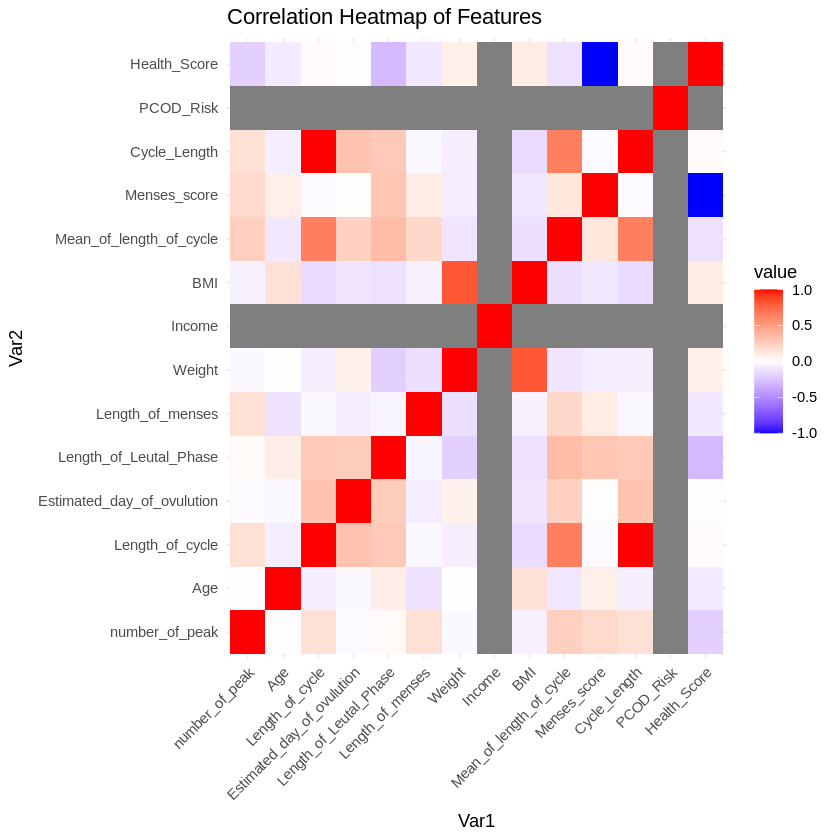

In [107]:
library(ggplot2)
library(reshape2)

melted_cor <- melt(cor_matrix)

ggplot(melted_cor, aes(Var1, Var2, fill = value)) +
  geom_tile() +
  scale_fill_gradient2(low = "blue", mid = "white", high = "red", midpoint = 0) +
  theme_minimal() +
  ggtitle("Correlation Heatmap of Features") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))
